# Contexto Social y Motivación del Estudio
- escribir texto

## Diseño del Muestreo y Levantamiento de Datos
- escribir texto 

In [4]:
from IPython.display import Markdown
import json

with open("prueba.json", "r", encoding="utf-8") as f:
    pimes_json = json.load(f)

with open("prueba_online.json", "r", encoding="utf-8") as f:
    pimeson_json = json.load(f)

tabla_fisica = "| Tienda | Latitud | Longitud | Evidence |\n"
tabla_fisica += "|--------|----------|-----------|-----------|\n"

for item in pimes_json:
    tabla_fisica += f"| {item['name']} | {item['latitude']} | {item['length']} | {item['evidence']} |\n"

tabla_online = "| Tienda | App | Link | Evidence |\n"
tabla_online += "|--------|----------|----------|-----------|\n"

for item in pimeson_json:
    tabla_online += f"| {item['name']} | {item['canal']} | {item['link']} | {item['evidence']} |\n"

display(Markdown("### Tiendas Físicas"))
display(Markdown(tabla_fisica))
display(Markdown("### Tiendas Online"))
display(Markdown(tabla_online))

### Tiendas Físicas

| Tienda | Latitud | Longitud | Evidence |
|--------|----------|-----------|-----------|
| VER PARA CREER S.U.R.L | 58468453168 | 84763135684 | p/mojon.png |
| Z PEREZ S.U.R.L. | 461815 | 1684865415 | p/serio.png |


### Tiendas Online

| Tienda | App | Link | Evidence |
|--------|----------|----------|-----------|
| la cuevita | telegram | wpswjrkfbwr | p/mojon.png |
| oe si | wasap | wehbfE | p/serio.png |


## Impacto Salarial de la Compra Mensual
- escribir texto

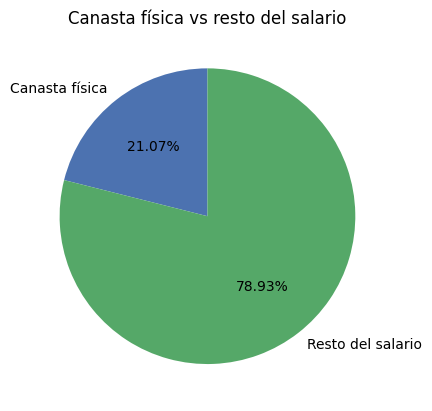

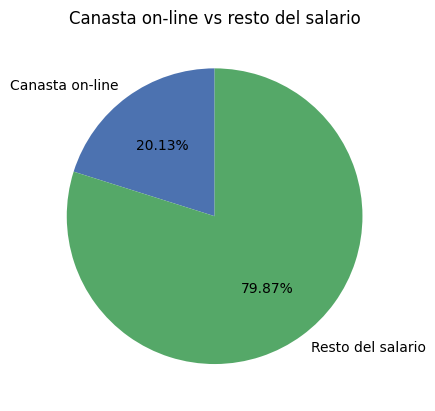

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import datos_static

# Físico
plt.pie([datos_static.precio_canasta_off, datos_static.salario_medio - datos_static.precio_canasta_off],
        labels=["Canasta física", "Resto del salario"],
        autopct="%1.2f%%", startangle=90, colors=["#4c72b0", "#55a868"])
plt.title("Canasta física vs resto del salario")
plt.show()

# Online
plt.pie([datos_static.precio_canasta_on, datos_static.salario_medio - datos_static.precio_canasta_on],
        labels=["Canasta on-line", "Resto del salario"],
        autopct="%1.2f%%", startangle=90, colors=["#4c72b0", "#55a868"])
plt.title("Canasta on-line vs resto del salario")
plt.show()

## Comparación del Costo Promedio por Producto
- escribir texto


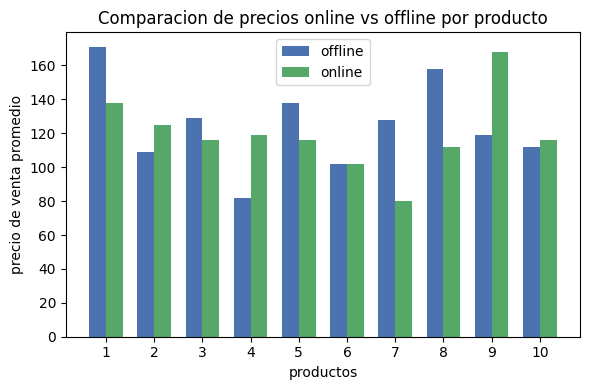

In [4]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import dic_work

# Preparar datos para matplotlib
cats = dic_work.lst_productos
s1   = dic_work.lst_promedio_off
s2   = dic_work.lst_promedio_on

x = np.arange(len(cats))        # posiciones de las categorías
width = 0.35                    # ancho de cada barra
color_off="#4c72b0"
color_on="#55a868"

# Graficar
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, s1, width, color=color_off, label="offline")
ax.bar(x + width/2, s2, width, color=color_on, label="online")

ax.set_xlabel("productos")
ax.set_ylabel("precio de venta promedio")
ax.set_title("Comparacion de precios online vs offline por producto")
ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.legend()

plt.tight_layout()
plt.show()

## Calculo del diff 
- escribir texto

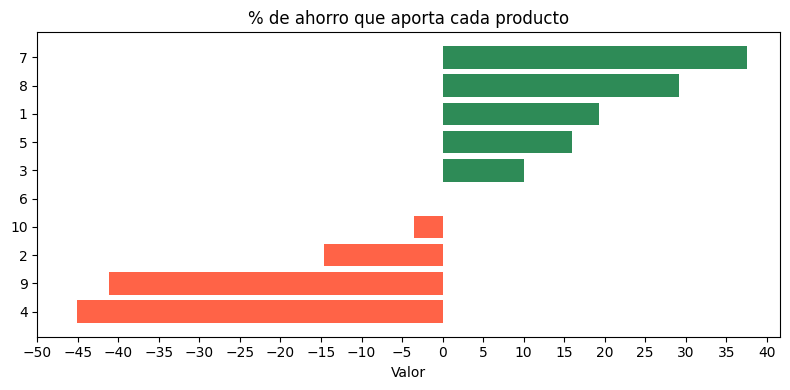

In [4]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import dic_work

# DataFrame de ejemplo
df = pl.DataFrame({
    "categoria": dic_work.lst_productos,
    "valor": dic_work.lst_diff
})

# --- lógica de color ---
df = df.with_columns(
    color=pl.when(pl.col("valor") < 0)
            .then(pl.lit("tomato"))
            .when(pl.col("valor") < 5 )
            .then(pl.lit("yellow"))
            .otherwise(pl.lit("seagreen"))
)
df = df.sort("valor", descending=True)
# --- gráfico ---
plt.figure(figsize=(8, 4))
plt.barh(df["categoria"], df["valor"], color=df["color"])
plt.xlabel("Valor")
plt.title("% de ahorro que aporta cada producto")
plt.gca().invert_yaxis()
plt.tight_layout()
min_x = df["valor"].min()
max_x = df["valor"].max()
plt.xticks(np.arange(np.floor(min_x/5)*5, np.ceil(max_x/5)*5 + 5, 5))
plt.show()

## Rango de variacion entre empresas por producto 
- escribir texto

In [9]:
from IPython.display import Markdown
import json
import dic_work
import metodos_pruebas

with open("prueba.json", "r") as f:
    pimes_json = json.load(f)

tabla = "| Producto | Tienda | OnLine |\n"
tabla += "|----------|-----------|-----------|\n"
tabla += f" {metodos_pruebas.convertir_tabla(dic_work.lst_productos, dic_work.lst_rango_off, dic_work.lst_rango_on)}"

Markdown(tabla)

| Producto | Tienda | OnLine |
|----------|-----------|-----------|
 | 1 | 3 | 30 |
| 2 | 19 | 35 |
| 3 | 39 | 12 |
| 4 | 14 | 11 |
| 5 | 30 | 20 |
| 6 | 70 | 72 |
| 7 | 46 | 10 |
| 8 | 10 | 26 |
| 9 | 11 | 0 |
| 10 | 16 | 20 |


## Rankin de daño por canal
- escribir texto

In [11]:
from IPython.display import Markdown
import dic_work

tabla_off = "| Tienda | Canasta | {%} |\n"
tabla_off += "|-----------|------------|--------------|\n"

for key, value in dic_work.dic_off_canasta.items():
    tabla_off += f"| {key} | {value[0]} | {round(value[1], 2)} |\n"

tabla_on = "| Tienda | Canasta | {%} |\n"
tabla_on += "|-----------|----------|------------|\n"

for key, value in dic_work.dic_on_canasta.items():
    tabla_on += f"| {key} | {value[0]} | {round(value[1], 2)} |\n"

display(Markdown("### Tiendas en Fisico"))
display(Markdown(tabla_off))
display(Markdown("### Tiendas OnLine"))
display(Markdown(tabla_on))

### Tiendas en Fisico

| Tienda | Canasta | {%} |
|-----------|------------|--------------|
| VER PARA CREER S.U.R.L | 714 | 33.71 |
| Z PEREZ S.U.R.L. | 534 | 0.0 |


### Tiendas OnLine

| Tienda | Canasta | {%} |
|-----------|----------|------------|
| la cuevita | 539 | 0.0 |
| oe si | 653 | 21.15 |


## Lollipop (punto anterior)
- escribir texto

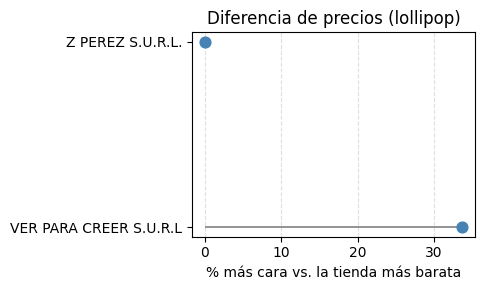

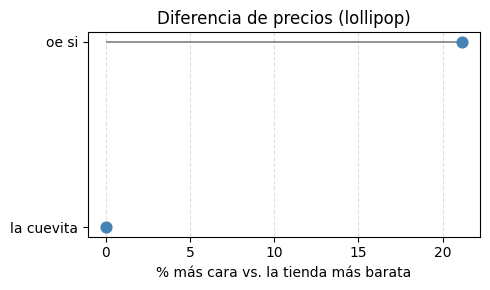

In [24]:
# pip install polars matplotlib numpy
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import dic_work

# Fisico
tiendas_off = []
pct_mas_cara_off = []

for key, value in dic_work.dic_off_canasta.items():
    tiendas_off.append(key)
    pct_mas_cara_off.append(value[1])

df = pl.DataFrame({"tienda": tiendas_off, "pct": pct_mas_cara_off})

# 2. Preparar coordenadas
y_pos = np.arange(len(df))
x_vals = df["pct"].to_numpy()

fig, ax = plt.subplots(figsize=(5, 3)) # 3. Lollipop plot 
ax.hlines(y_pos, xmin=0, xmax=x_vals, color="grey", linewidth=1.2)# líneas (palos)
ax.scatter(x_vals, y_pos, color="steelblue", zorder=3, s=60) # puntos (bolas)

# decoración
ax.set_yticks(y_pos)
ax.set_yticklabels(df["tienda"])
ax.set_xlabel("% más cara vs. la tienda más barata")
ax.set_title("Diferencia de precios (lollipop)")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Online
tiendas_on = []
pct_mas_cara_on = []

for key, value in dic_work.dic_on_canasta.items():
    tiendas_on.append(key)
    pct_mas_cara_on.append(value[1])

df = pl.DataFrame({"tienda": tiendas_on, "pct": pct_mas_cara_on})

# 2. Preparar coordenadas
y_pos = np.arange(len(df))
x_vals = df["pct"].to_numpy()

fig, ax = plt.subplots(figsize=(5, 3)) # 3. Lollipop plot 
ax.hlines(y_pos, xmin=0, xmax=x_vals, color="grey", linewidth=1.2)# líneas (palos)
ax.scatter(x_vals, y_pos, color="steelblue", zorder=3, s=60) # puntos (bolas)

# decoración
ax.set_yticks(y_pos)
ax.set_yticklabels(df["tienda"])
ax.set_xlabel("% más cara vs. la tienda más barata")
ax.set_title("Diferencia de precios (lollipop)")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()